# Model Inference, Comparison & Export

This notebook demonstrates:
1. **Model Inference**: Running predictions on sample images from the holdout set
2. **Visualization**: Showing model predictions with confidence scores
3. **Challenging Cases**: Identifying images where models struggle
4. **Teacher vs Student Comparison**: Finding cases where teacher succeeds but student fails
5. **Model Export**: Saving models to ONNX and TorchScript formats for deployment

In [1]:
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import torch

warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    CHECKPOINTS_DIR,
    MODELS_DIR,
    PROCESSED_DIR,
    DataConfig,
    StudentConfig,
    TeacherConfig,
    get_device,
    set_seed,
)
from src.data.dataset import HAM10000Dataset, get_eval_transforms
from src.evaluation.inference import (
    analyze_predictions,
    get_all_predictions,
    load_model_from_checkpoint,
    plot_confidence_distribution,
    plot_prediction_grid,
)
from src.models.architectures import StudentModel, TeacherModel

set_seed(42)
DEVICE = get_device()
print(f"Using device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")

Using device: mps
Project root: /Users/ryan.healy/DS_MSDS/Deep_Learning_Final_Project


## 1. Load Best Teacher and Student Models

Based on evaluation results, we load:
- **Best Teacher**: EfficientNet-B1 (highest ROC-AUC: 0.919)
- **Best Student**: MobileNetV3-Small with T=2.0, alpha=0.9

In [2]:
# Load best teacher (EfficientNet-B1)
teacher_config = TeacherConfig(architecture="efficientnet_b1")
teacher_checkpoint = CHECKPOINTS_DIR / "teacher_efficientnet_b1_focal_best.pth"
teacher_model = TeacherModel(teacher_config)
teacher_model = load_model_from_checkpoint(teacher_model, teacher_checkpoint, DEVICE)
print(f"Loaded Teacher: EfficientNet-B1 ({teacher_model.count_parameters()['total']:,} params)")

# Load best student (T=2.0, alpha=0.9)
student_config = StudentConfig()
student_checkpoint = CHECKPOINTS_DIR / "student_T2.0_alpha0.9_best.pth"
student_model = StudentModel(student_config)
student_model = load_model_from_checkpoint(student_model, student_checkpoint, DEVICE)
print(f"Loaded Student: MobileNetV3-Small ({student_model.count_parameters()['total']:,} params)")
print(f"  Student size: {student_model.get_model_size_mb():.2f} MB")

Loaded Teacher: EfficientNet-B1 (6,514,465 params)
Loaded Student: MobileNetV3-Small (1,518,881 params)
  Student size: 5.84 MB


## 2. Load Holdout Dataset

In [3]:
# Load holdout data
holdout_csv = PROCESSED_DIR / "holdout_data.csv"
holdout_df = pd.read_csv(holdout_csv)

data_config = DataConfig()
eval_transforms = get_eval_transforms(data_config)
holdout_dataset = HAM10000Dataset(holdout_csv, transform=eval_transforms, config=data_config)

print(f"Holdout set: {len(holdout_dataset)} samples")
print(f"  Melanoma (positive): {holdout_dataset.num_positive}")
print(f"  Non-melanoma (negative): {holdout_dataset.num_negative}")
print(f"  Prevalence: {holdout_dataset.prevalence:.2%}")

Holdout set: 1513 samples
  Melanoma (positive): 172
  Non-melanoma (negative): 1341
  Prevalence: 11.37%


## 3. Run Inference on Holdout Set

In [4]:
# Get predictions for all holdout samples
print("Running inference on holdout set...")
predictions_df = get_all_predictions(teacher_model, student_model, holdout_dataset, DEVICE)

# Summary statistics
analysis = analyze_predictions(predictions_df)

print("\n=== Holdout Set Performance ===")
print(f"Teacher Accuracy: {analysis['teacher_accuracy']:.2%}")
print(f"Student Accuracy: {analysis['student_accuracy']:.2%}")
print("\nConfusion Analysis:")
print(f"  Both correct: {analysis['both_correct']}")
print(f"  Both wrong: {analysis['both_wrong']}")
print(f"  Teacher only correct: {analysis['teacher_only_correct']}")
print(f"  Student only correct: {analysis['student_only_correct']}")

Running inference on holdout set...

=== Holdout Set Performance ===
Teacher Accuracy: 86.38%
Student Accuracy: 84.67%

Confusion Analysis:
  Both correct: 1197
  Both wrong: 122
  Teacher only correct: 110
  Student only correct: 84


## 4. Visualize Sample Predictions

### 4.1 Correct Predictions (Easy Cases)

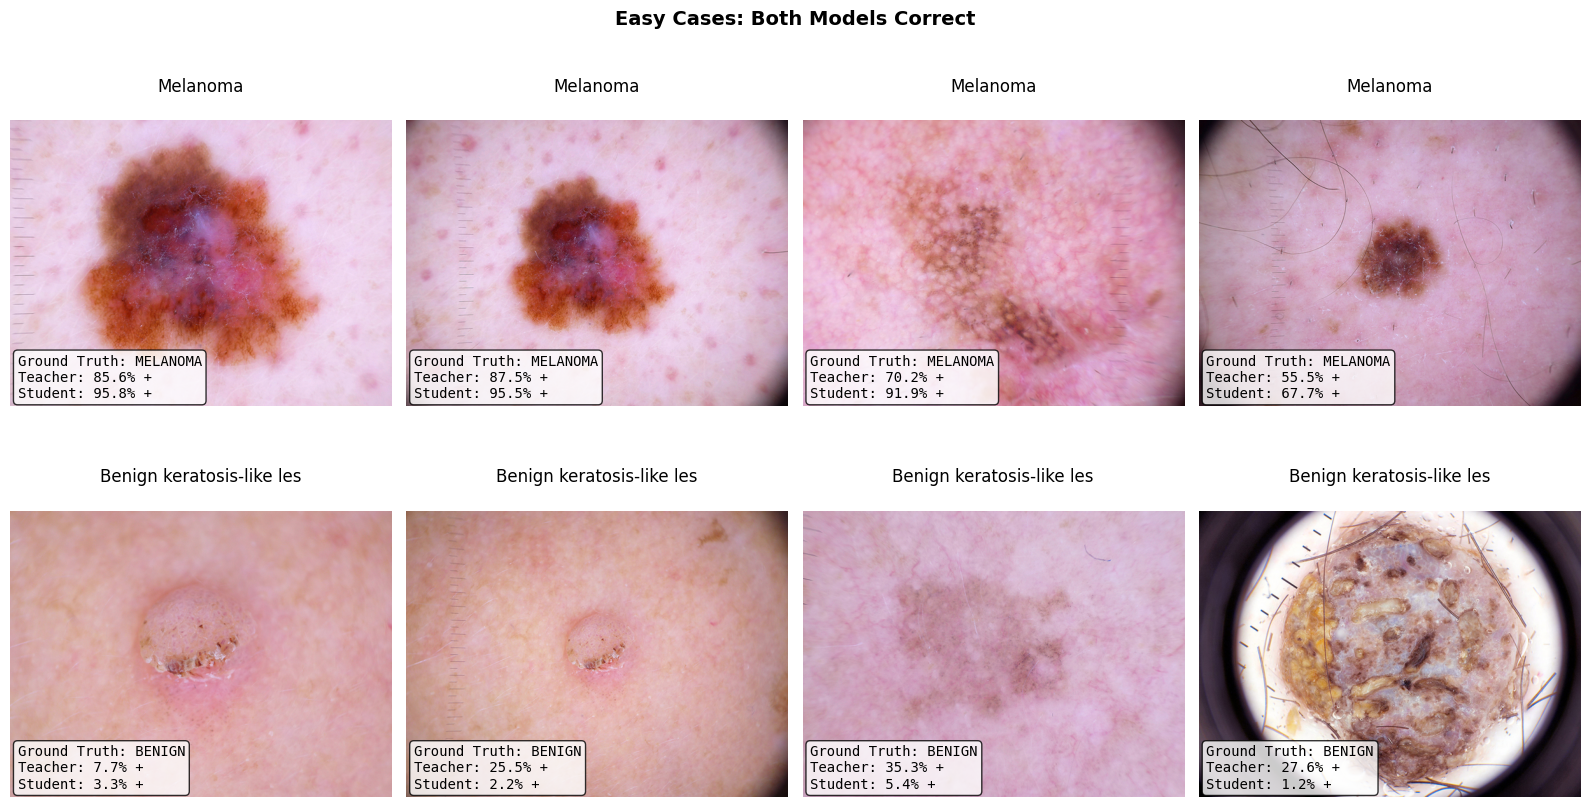

In [5]:
# Output directory
output_dir = PROJECT_ROOT / "artifacts" / "imgs" / "02_inference"
output_dir.mkdir(parents=True, exist_ok=True)

# Find cases where both models are correct
both_correct = predictions_df[
    (predictions_df['teacher_correct']) & (predictions_df['student_correct'])
]

# Sample from each class
melanoma_correct = both_correct[both_correct['true_label'] == 1].head(4)
benign_correct = both_correct[both_correct['true_label'] == 0].head(4)
samples = pd.concat([melanoma_correct, benign_correct])

plot_prediction_grid(samples, "both correct", "Easy Cases: Both Models Correct",
                     save_path=output_dir / "easy_cases.png")
plt.show()

### 4.2 Challenging Cases (Both Models Wrong)

Found 122 challenging cases where both models failed.


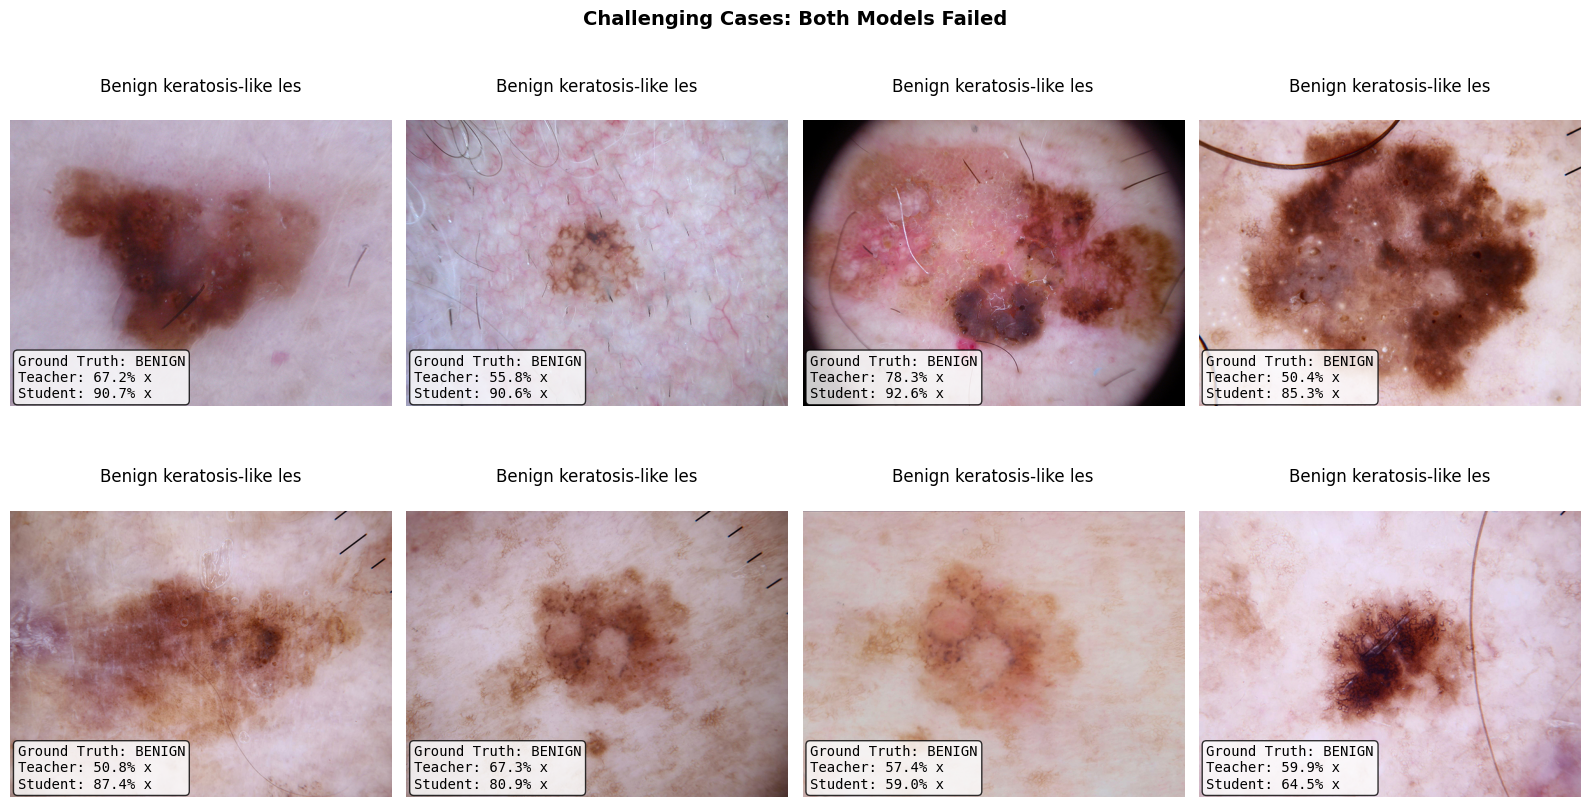

In [6]:
# Find cases where both models are wrong
both_wrong = predictions_df[
    (~predictions_df['teacher_correct']) & (~predictions_df['student_correct'])
]

print(f"Found {len(both_wrong)} challenging cases where both models failed.")

if len(both_wrong) > 0:
    plot_prediction_grid(both_wrong, "both wrong", "Challenging Cases: Both Models Failed",
                         save_path=output_dir / "challenging_cases.png")
    plt.show()

### 4.3 Knowledge Gap: Teacher Correct, Student Wrong

These cases show where knowledge distillation could be improved.

Found 110 cases where teacher succeeds but student fails.

Breakdown by lesion type:
lesion_type
Melanocytic nevi                 58
Benign keratosis-like lesions    23
Actinic keratoses                13
Basal cell carcinoma              6
Dermatofibroma                    4
Melanoma                          4
Vascular lesions                  2
Name: count, dtype: int64


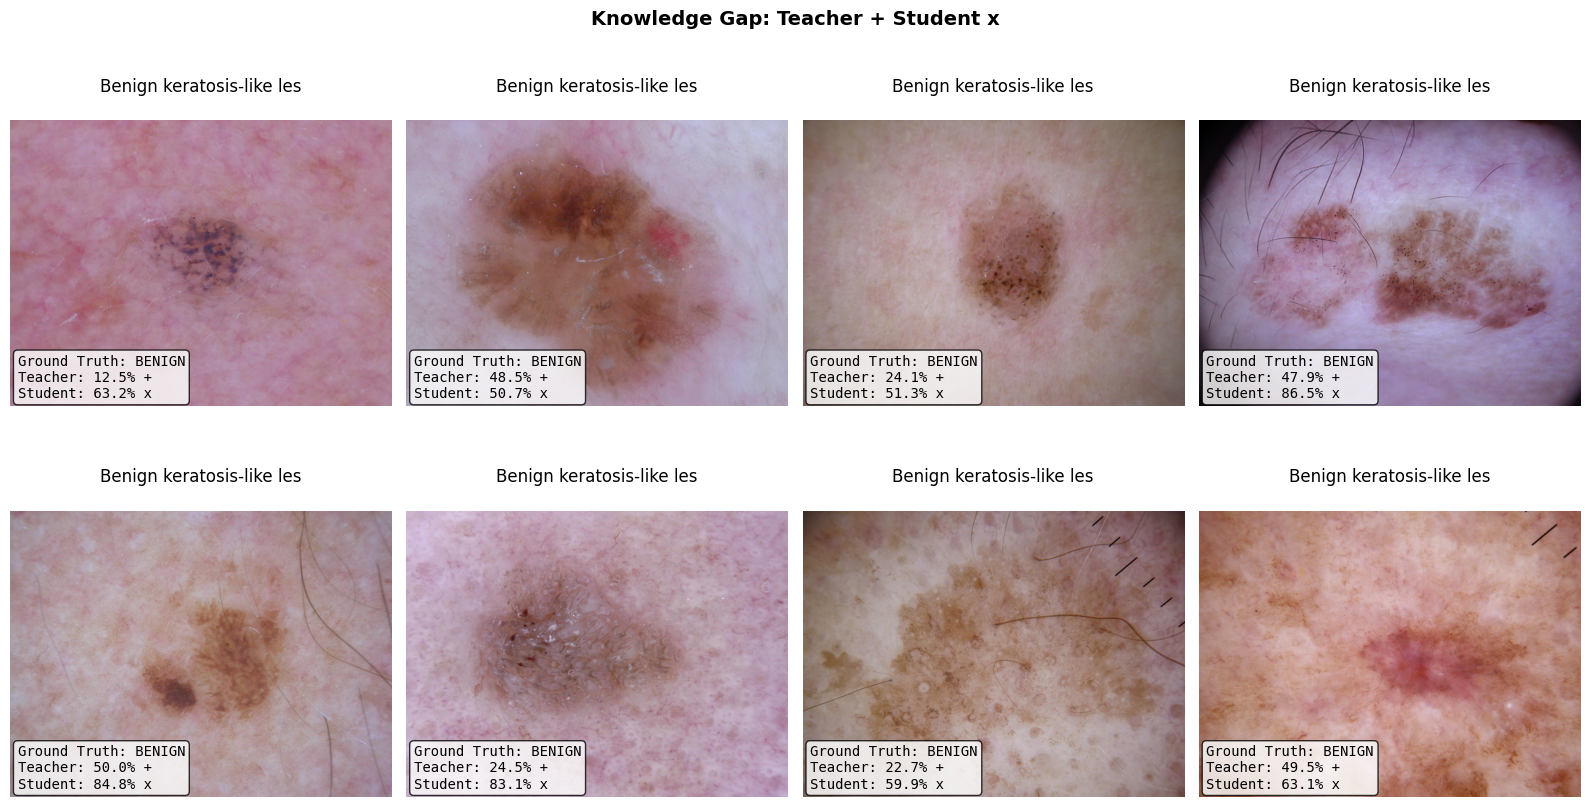

In [7]:
# Find cases where teacher is correct but student is wrong
teacher_only_correct = predictions_df[
    (predictions_df['teacher_correct']) & (~predictions_df['student_correct'])
]

print(f"Found {len(teacher_only_correct)} cases where teacher succeeds but student fails.")

if len(teacher_only_correct) > 0 and 'lesion_type' in teacher_only_correct.columns:
    print("\nBreakdown by lesion type:")
    print(teacher_only_correct['lesion_type'].value_counts())

    plot_prediction_grid(teacher_only_correct, "teacher only", "Knowledge Gap: Teacher + Student x",
                         save_path=output_dir / "teacher_vs_student.png")
    plt.show()

### 4.4 Confidence Analysis

Visualize confidence distributions for correct vs incorrect predictions.

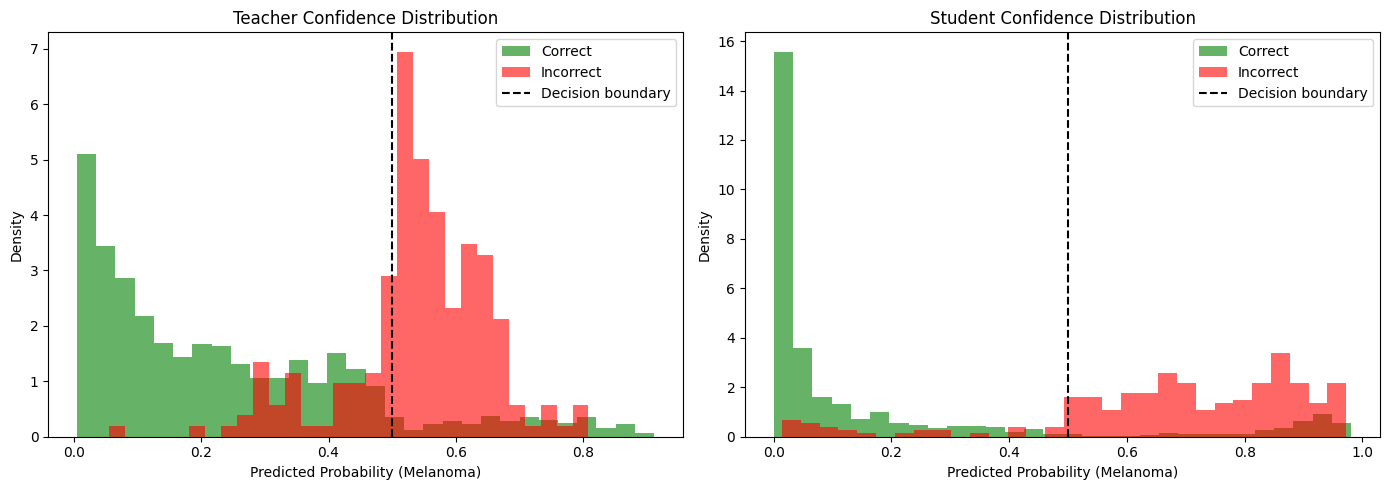

In [8]:
plot_confidence_distribution(predictions_df, save_path=output_dir / "confidence_distribution.png")
plt.show()

---

## 5. Export Models to ONNX and TorchScript

Export the best models for production deployment:
- **ONNX**: Cross-platform inference (TensorRT, ONNX Runtime, CoreML, etc.)
- **TorchScript**: PyTorch-native deployment (mobile, C++, server)

In [9]:
from src.models.export import (
    benchmark_onnx_inference,
    benchmark_pytorch_inference,
    export_to_onnx,
    export_to_torchscript,
    get_export_summary,
    validate_onnx,
    validate_torchscript,
)

# Create export directory
EXPORT_DIR = MODELS_DIR / "exported"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Sample input for tracing
data_config = DataConfig()
DUMMY_INPUT = torch.randn(1, 3, data_config.image_size, data_config.image_size).to(DEVICE)

print(f"Export directory: {EXPORT_DIR}")
print(f"Input shape: {DUMMY_INPUT.shape}")

Export directory: /Users/ryan.healy/DS_MSDS/Deep_Learning_Final_Project/models/exported
Input shape: torch.Size([1, 3, 224, 224])


### 5.1 Export to ONNX

In [10]:
# Export both models to ONNX
teacher_onnx = export_to_onnx(teacher_model, "teacher_efficientnet_b1", DUMMY_INPUT, EXPORT_DIR)
student_onnx = export_to_onnx(student_model, "student_mobilenetv3_small", DUMMY_INPUT, EXPORT_DIR)

Exported teacher_efficientnet_b1 to ONNX: teacher_efficientnet_b1.onnx (24.84 MB)
Exported student_mobilenetv3_small to ONNX: student_mobilenetv3_small.onnx (5.81 MB)


### 5.2 Validate ONNX Models

In [11]:
# Validate both models
validate_onnx(teacher_onnx.path, teacher_model, DUMMY_INPUT)
validate_onnx(student_onnx.path, student_model, DUMMY_INPUT)

teacher_efficientnet_b1.onnx: Max difference = 3.10e-06 (PASS)
student_mobilenetv3_small.onnx: Max difference = 0.00e+00 (PASS)


np.True_

### 5.3 Export to TorchScript

In [12]:
# Export both models to TorchScript
teacher_ts = export_to_torchscript(teacher_model, "teacher_efficientnet_b1", DUMMY_INPUT, EXPORT_DIR)
student_ts = export_to_torchscript(student_model, "student_mobilenetv3_small", DUMMY_INPUT, EXPORT_DIR)

Exported teacher_efficientnet_b1 to TorchScript: teacher_efficientnet_b1.pt (24.81 MB)
Exported student_mobilenetv3_small to TorchScript: student_mobilenetv3_small.pt (5.81 MB)


### 5.4 Validate TorchScript Models

In [13]:
# Validate both models
validate_torchscript(teacher_ts.path, teacher_model, DUMMY_INPUT)
validate_torchscript(student_ts.path, student_model, DUMMY_INPUT)

teacher_efficientnet_b1.pt: Max difference = 6.32e-06 (PASS)
student_mobilenetv3_small.pt: Max difference = 1.43e-06 (PASS)


np.True_

### 5.5 Benchmark Inference Speed

In [14]:
print(f"\n=== Inference Benchmark ({str(DEVICE).upper()}) ===")
print(f"Input: {DUMMY_INPUT.shape}\n")

# PyTorch models
print("PyTorch:")
teacher_pt_time, _ = benchmark_pytorch_inference(teacher_model, DUMMY_INPUT, name="  Teacher (EfficientNet-B1)")
student_pt_time, _ = benchmark_pytorch_inference(student_model, DUMMY_INPUT, name="  Student (MobileNetV3-Small)")

# ONNX Runtime
print("\nONNX Runtime:")
teacher_onnx_time, _ = benchmark_onnx_inference(teacher_onnx.path, DUMMY_INPUT, name="  Teacher (EfficientNet-B1)")
student_onnx_time, _ = benchmark_onnx_inference(student_onnx.path, DUMMY_INPUT, name="  Student (MobileNetV3-Small)")

print("\n=== Speedup Summary ===")
print(f"Student vs Teacher speedup: {teacher_pt_time/student_pt_time:.1f}x")


=== Inference Benchmark (MPS) ===
Input: torch.Size([1, 3, 224, 224])

PyTorch:
  Teacher (EfficientNet-B1): 9.09 +/- 0.52 ms
  Student (MobileNetV3-Small): 3.73 +/- 0.24 ms

ONNX Runtime:
  Teacher (EfficientNet-B1): 6.25 +/- 0.19 ms
  Student (MobileNetV3-Small): 1.18 +/- 0.07 ms

=== Speedup Summary ===
Student vs Teacher speedup: 2.4x


### 5.6 Export Summary

In [15]:
# Summary of exported models
summary = get_export_summary(EXPORT_DIR)
summary_df = pd.DataFrame(summary)

print("\n" + "="*60)
print("EXPORTED MODELS SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))
print(f"\nExport directory: {EXPORT_DIR}")


EXPORTED MODELS SUMMARY
                          File Format Size (MB)
student_mobilenetv3_small.onnx   ONNX      5.81
  student_mobilenetv3_small.pt     PT      5.81
  teacher_efficientnet_b1.onnx   ONNX     24.84
    teacher_efficientnet_b1.pt     PT     24.81

Export directory: /Users/ryan.healy/DS_MSDS/Deep_Learning_Final_Project/models/exported


---

## 6. Usage Instructions

### Running ONNX Models

```python
import onnxruntime as ort
import numpy as np
from PIL import Image
from torchvision import transforms

# Load ONNX model
session = ort.InferenceSession("models/exported/student_mobilenetv3_small.onnx")

# Preprocess image
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image = Image.open("path/to/image.jpg").convert("RGB")
input_tensor = transform(image).unsqueeze(0).numpy()

# Run inference
logit = session.run(None, {"input": input_tensor})[0]
probability = 1 / (1 + np.exp(-logit))  # sigmoid
prediction = "Melanoma" if probability > 0.5 else "Benign"
```

### Running TorchScript Models

```python
import torch
from PIL import Image
from torchvision import transforms

# Load TorchScript model
model = torch.jit.load("models/exported/student_mobilenetv3_small.pt")
model.eval()

# Preprocess image (same as above)
with torch.no_grad():
    logit = model(input_tensor)
    probability = torch.sigmoid(logit).item()
    prediction = "Melanoma" if probability > 0.5 else "Benign"
```

In [16]:
# Final summary

print(f"""
Key Results:
  Teacher (EfficientNet-B1): {teacher_model.count_parameters()['total']:,} params
  Student (MobileNetV3-Small): {student_model.count_parameters()['total']:,} params
  Parameter reduction: {(1 - student_model.count_parameters()['total']/teacher_model.count_parameters()['total']):.1%}

Exported Models:
  ONNX: models/exported/*.onnx
  TorchScript: models/exported/*.pt
""")


Key Results:
  Teacher (EfficientNet-B1): 6,514,465 params
  Student (MobileNetV3-Small): 1,518,881 params
  Parameter reduction: 76.7%

Exported Models:
  ONNX: models/exported/*.onnx
  TorchScript: models/exported/*.pt



In [17]:
!du -h ../models/exported/*

5.8M	../models/exported/student_mobilenetv3_small.onnx
6.1M	../models/exported/student_mobilenetv3_small.pt
 25M	../models/exported/teacher_efficientnet_b1.onnx
 25M	../models/exported/teacher_efficientnet_b1.pt
